# Cross validation

Model selection by 5-fold cross validation.

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy, LMCVariationalStrategy
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


N = 100
x = torch.linspace(0, 1, N).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

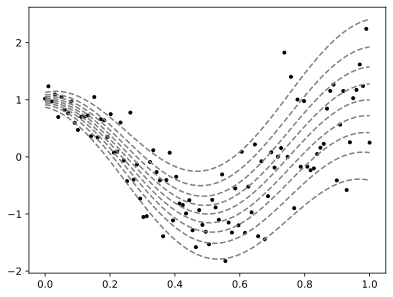

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

In [ ]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

x_train_list, y_train_list, x_test_list, y_test_list = [], [], [], []
for train_idx, test_idx in kf.split(x.cpu()):
    x_train_list.append(x[train_idx])
    y_train_list.append(y[train_idx])
    x_test_list.append(x[test_idx])
    y_test_list.append(y[test_idx])

x_train_cv = torch.stack(x_train_list).to(device)
y_train_cv = torch.stack(y_train_list).to(device)
x_test_cv = torch.stack(x_test_list).to(device)
y_test_cv = torch.stack(y_test_list).to(device)

## Direct GPQR (correlated quantiles)

In [ ]:
from gpytorch_qr.models import DirectQuantileGP
from gpytorch_qr.likelihoods import DirectQuantileLikelihood


class CVMultitaskQuantileGP(DirectQuantileGP):
    def __init__(self, inducing_points, num_quantiles, batch_shape, num_latents):
        N, D = inducing_points.size()
        batch_shape = torch.Size([*batch_shape, num_latents])
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=batch_shape,
        )
        variational_strategy = LMCVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_tasks=num_quantiles,
            num_latents=num_latents,
        )

        mean_module = ConstantMean(batch_shape=batch_shape)
        covar_module = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=batch_shape),
            batch_shape=batch_shape,
        )
        super().__init__(variational_strategy, mean_module, covar_module)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
num_latents = len(q) - 2
mtgpqr = CVMultitaskQuantileGP(inducing_points, len(q), (K,), num_latents).to(device)
q_expanded = q.unsqueeze(0).expand(K, -1)
likelihood_mtgpqr = DirectQuantileLikelihood(q_expanded).to(device)

In [ ]:
mll = VariationalELBO(likelihood_mtgpqr, mtgpqr, num_data=y_train_cv.shape[-1])
optimizer = torch.optim.Adam(
    list(mtgpqr.parameters()) + list(likelihood_mtgpqr.parameters()),
    lr=0.001,
)

mtgpqr_train_losses, mtgpqr_test_losses = [], []
for _ in range(n_epochs):
    mtgpqr.train()
    likelihood_mtgpqr.train()

    output = mtgpqr(x_train_cv)
    train_loss = -mll(output, y_train_cv)
    train_loss.sum().backward()
    optimizer.step()
    optimizer.zero_grad()

    mtgpqr.eval()
    likelihood_mtgpqr.eval()
    with torch.no_grad():
        output = mtgpqr(x_test_cv)
        test_loss = -mll(output, y_test_cv)

    mtgpqr_train_losses.append(train_loss.mean().item() / len(q))
    mtgpqr_test_losses.append(test_loss.mean().item() / len(q))

## Center-gap GPQR (correlated gaps)

In [ ]:
from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CGLmcVariationalStrategy
from gpytorch_qr.likelihoods import CenterGapQuantileLikelihood


class CVMultitaskCenterGapQuantileGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
        num_folds,
    ):
        N, D = inducing_points.size()
        batch_shape = torch.Size([num_folds, num_latents])
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=batch_shape,
        )
        variational_strategy = CGLmcVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_latents=num_latents,
        )

        mean = CenterGapMean(
            ConstantMean(batch_shape=torch.Size([num_folds, 1])),
            ConstantMean(batch_shape=torch.Size([num_folds, num_latents - 1])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=batch_shape),
            batch_shape=batch_shape,
        )
        super().__init__(variational_strategy, mean, covar, num_lower_quantiles)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = (q - 0.5).abs().argmin().item()
num_latents = len(q) - 2
mtgpqr_cg = CVMultitaskCenterGapQuantileGP(
    inducing_points, len(q), central_q_index, num_latents, K
).to(device)
likelihood_mtgpqr_cg = CenterGapQuantileLikelihood(
    q.unsqueeze(0), central_q_index, torch.zeros((K, len(q)))
).to(device)

In [ ]:
mll = VariationalELBO(likelihood_mtgpqr_cg, mtgpqr_cg, num_data=y_train_cv.shape[1])
optimizer = torch.optim.Adam(
    list(mtgpqr_cg.parameters()) + list(likelihood_mtgpqr_cg.parameters()),
    lr=0.001,
)

mtgpqr_cg_train_losses, mtgpqr_cg_test_losses = [], []
for _ in range(n_epochs):
    mtgpqr_cg.train()
    likelihood_mtgpqr_cg.train()

    output = mtgpqr_cg(x_train_cv)
    train_loss = -mll(output, y_train_cv)
    train_loss.sum().backward()
    optimizer.step()
    optimizer.zero_grad()

    mtgpqr_cg.eval()
    likelihood_mtgpqr_cg.eval()
    with torch.no_grad():
        output = mtgpqr_cg(x_test_cv)
        test_loss = -mll(output, y_test_cv)

    mtgpqr_cg_train_losses.append(train_loss.mean().item() / len(q))
    mtgpqr_cg_test_losses.append(test_loss.mean().item() / len(q))

## Plot loss by epoch

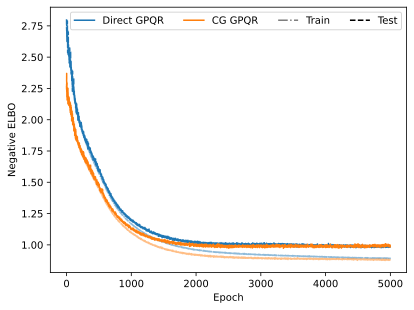

In [ ]:
from matplotlib.lines import Line2D

colors = plt.cm.tab10.colors

losses = [
    [mtgpqr_train_losses, mtgpqr_test_losses],
    [mtgpqr_cg_train_losses, mtgpqr_cg_test_losses],
]

for (train_losses, test_losses), color in zip(losses, colors):
    plt.plot(train_losses, color=color, linestyle="-.", alpha=0.5)
    plt.plot(test_losses, color=color, linestyle="--")

model_handles = [
    Line2D([0], [0], color=colors[i], linestyle="-") for i in range(len(losses))
]
style_handles = [
    Line2D([0], [0], color="k", linestyle="-.", alpha=0.5),
    Line2D([0], [0], color="k", linestyle="--"),
]

handles = model_handles + style_handles
labels = ["Direct GPQR", "CG GPQR", "Train", "Test"]
plt.legend(handles=handles, labels=labels, ncols=4)

plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.show()